# Topic Comparison — Joint UMAP & Density Analysis
Comparative visualisations of the papers and iGEM-teams topic models projected into a shared embedding space.

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import cycle
from umap import UMAP

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
EMBEDS = os.path.join(ASSETS, 'embeddings')

In [21]:
# Load papers dataset (only columns needed downstream)
papers = pd.read_csv(os.path.join(ASSETS, 'synbio_openalex.txt'), sep='\t')
papers['cited_by_count'] = pd.to_numeric(papers['cited_by_count'], errors='coerce').fillna(0).astype(int)
papers['publication_year'] = pd.to_numeric(papers['publication_year'], errors='coerce')

# Load papers topic assignments and names (used by UMAP plotting helpers)
doc_topics = pd.read_csv(os.path.join(MODELS, 'papers_doc_topics.txt'), sep='\t')
topic_names = pd.read_csv(os.path.join(MODELS, 'papers_topic_names.txt'), sep='\t')

print(f"Papers: {len(papers):,}")
print(f"Topics: {doc_topics['topic'].nunique()} (incl. outlier -1)")

Papers: 24,202
Topics: 264 (incl. outlier -1)


## Topic model plots — Joint UMAP space

Both papers and teams embeddings come from the same `all-MiniLM-L6-v2` encoder (384-dim), so we project **all documents together** into a single 2D UMAP manifold. This ensures proximity between a paper and a team project is directly interpretable — no post-hoc alignment needed.

In [22]:
# Load embeddings for both corpora
papers_emb = np.load(os.path.join(EMBEDS, 'papers_embeddings.npy'))
teams_emb  = np.load(os.path.join(EMBEDS, 'teams_embeddings.npy'))

# Load teams topic assignments and names
teams_doc_topics  = pd.read_csv(os.path.join(MODELS, 'teams_doc_topics.txt'), sep='\t')
teams_topic_names = pd.read_csv(os.path.join(MODELS, 'teams_topic_names.txt'), sep='\t')

n_papers = len(papers_emb)
n_teams  = len(teams_emb)
print(f"Papers embeddings: {papers_emb.shape}")
print(f"Teams embeddings:  {teams_emb.shape}")
assert n_papers == len(doc_topics), "Papers embeddings vs doc_topics mismatch"
assert n_teams  == len(teams_doc_topics), "Teams embeddings vs doc_topics mismatch"

Papers embeddings: (24202, 384)
Teams embeddings:  (4548, 384)


In [23]:
# Joint 2D UMAP: stack papers + teams, project together
all_emb = np.vstack([papers_emb, teams_emb])

umap_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=SEED,
)
all_xy = umap_2d.fit_transform(all_emb)

papers_xy = all_xy[:n_papers]
teams_xy  = all_xy[n_papers:]
print(f"Joint projection: {all_xy.shape}  (papers {papers_xy.shape}, teams {teams_xy.shape})")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Joint projection: (28750, 2)  (papers (24202, 2), teams (4548, 2))


In [24]:
# Color palette (recycled)
palette = [
    "#f00f15", "#2270e7", "#e5e510", "#ff8103", "#4f3dd1",
    "#26cc3a", "#ec058e", "#9cb8c2", "#fffdd0", "#b40e68",
    "#5afb5a", "#beaed4", "#fdc086", "#99fdff", "#c430ff",
    "#e4dbe0", "#bf5b17", "#666666",
]

def build_plot_df(xy, dt, tn, id_col='id', size_col=None, size_df=None):
    """Build a plotting dataframe with x, y, topic, color, global_name."""
    df = dt.copy()
    df['x'] = xy[:, 0]
    df['y'] = xy[:, 1]
    df = df.merge(tn[['topic', 'global_name']], on='topic', how='left')
    if size_col and size_df is not None:
        df = df.merge(
            size_df[[id_col, size_col]].drop_duplicates(id_col),
            on=id_col, how='left',
        )
    # Assign colors
    topics_sorted = sorted(df.loc[df['topic'] >= 0, 'topic'].unique())
    cc = cycle(palette)
    cmap = {t: next(cc) for t in topics_sorted}
    cmap[-1] = '#d3d3d3'
    df['color'] = df['topic'].map(cmap)
    return df, topics_sorted

# Papers plotting dataframe
df_papers, papers_topics = build_plot_df(
    papers_xy, doc_topics, topic_names,
    id_col='id', size_col='cited_by_count', size_df=papers,
)

# Teams plotting dataframe
df_teams, teams_topics = build_plot_df(
    teams_xy, teams_doc_topics, teams_topic_names,
    id_col='UT',
)

# Shared axis limits from the joint UMAP projection (consistent across all plots)
_pad = 1.5
XLIM = (all_xy[:, 0].min() - _pad, all_xy[:, 0].max() + _pad)
YLIM = (all_xy[:, 1].min() - _pad, all_xy[:, 1].max() + _pad)

print(f"Papers: {len(df_papers):,} pts, {len(papers_topics)} topics")
print(f"Teams:  {len(df_teams):,} pts, {len(teams_topics)} topics")
print(f"Shared axis limits: x={XLIM}, y={YLIM}")

Papers: 24,202 pts, 263 topics
Teams:  4,548 pts, 161 topics
Shared axis limits: x=(np.float32(-6.5288377), np.float32(19.218245)), y=(np.float32(-2.0912228), np.float32(16.082216))


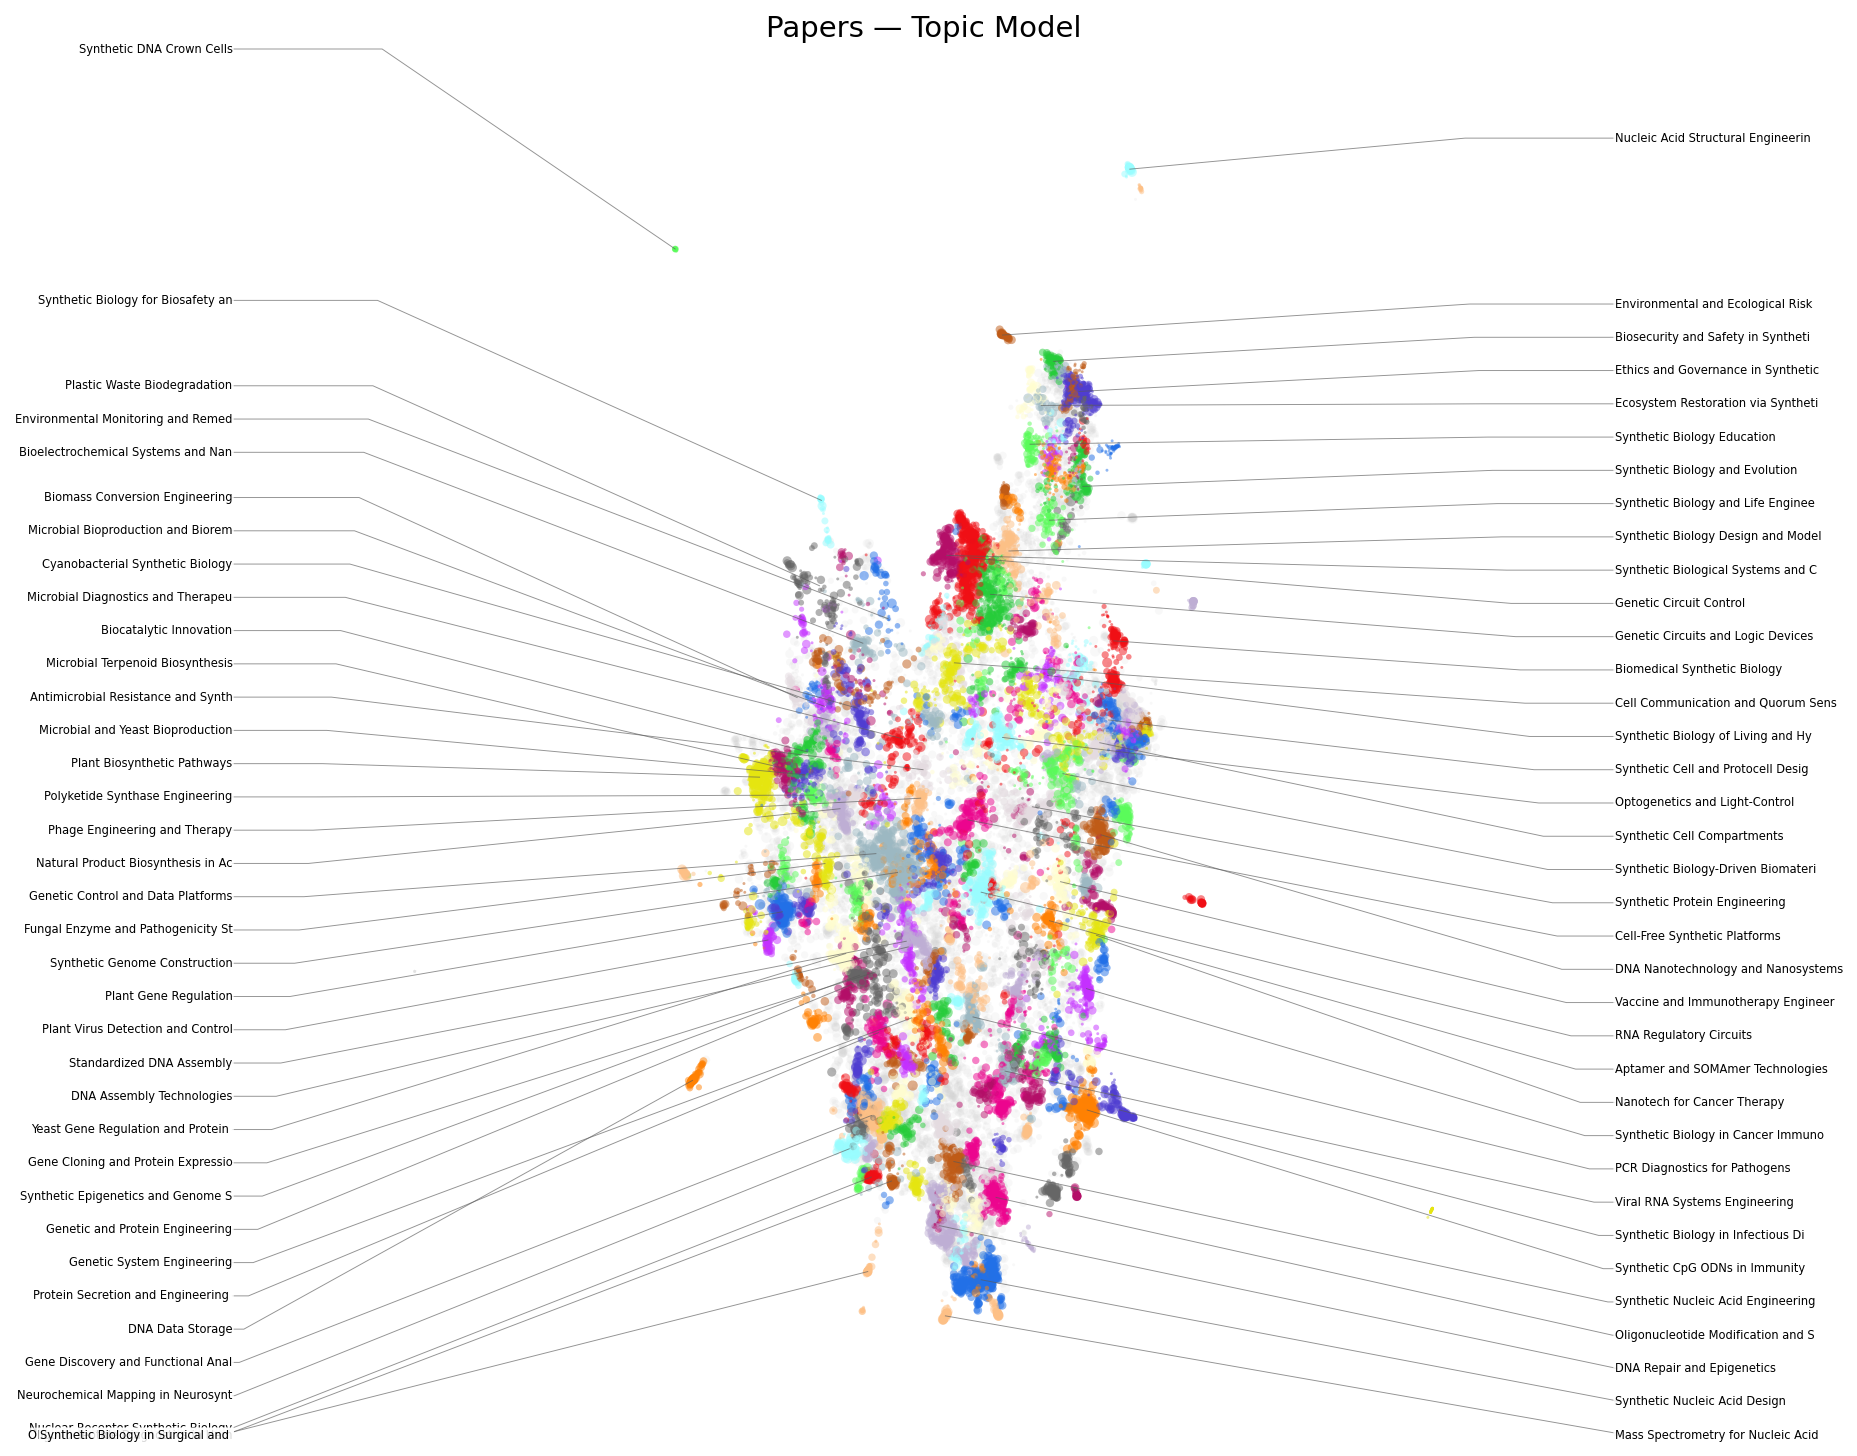

In [ ]:
def _spread_targets(y_values, y_min, y_max, min_gap):
    """Spread y-positions to keep labels from overlapping."""
    if len(y_values) == 0:
        return np.array([], dtype=float)

    ys = np.array(y_values, dtype=float)
    ys = np.clip(ys, y_min, y_max)

    # Forward pass (top to bottom): enforce minimum separation
    for i in range(1, len(ys)):
        if ys[i - 1] - ys[i] < min_gap:
            ys[i] = ys[i - 1] - min_gap

    # If we fell below bounds, shift up and re-enforce constraints
    if ys[-1] < y_min:
        ys += (y_min - ys[-1])
        for i in range(len(ys) - 2, -1, -1):
            if ys[i] - ys[i + 1] < min_gap:
                ys[i] = ys[i + 1] + min_gap

    # If top exceeds bound after corrections, shift down
    if ys[0] > y_max:
        ys -= (ys[0] - y_max)

    return np.clip(ys, y_min, y_max)

def _pick_labels_for_side(sub, y_min, y_max, min_gap, max_labels=None):
    """Select a manageable, vertically spread subset of labels for one side."""
    if sub.empty:
        return sub

    capacity = max(1, int(np.floor((y_max - y_min) / min_gap)) + 1)
    target_n = capacity if max_labels is None else min(capacity, max_labels)
    target_n = min(target_n, len(sub))
    if len(sub) <= target_n:
        return sub.sort_values('cy', ascending=False).reset_index(drop=True)

    work = sub.copy()
    # Bin by y and keep the largest topic per bin to preserve vertical spread
    bins = np.linspace(y_min, y_max, target_n + 1)
    work['y_bin'] = np.clip(np.digitize(work['cy'], bins) - 1, 0, target_n - 1)
    primary = work.sort_values(['y_bin', 'n_docs'], ascending=[True, False]).groupby('y_bin', as_index=False).head(1)

    # Fill remaining slots by size if some bins were empty
    if len(primary) < target_n:
        used = set(primary.index.tolist())
        rest = work.loc[~work.index.isin(used)].sort_values('n_docs', ascending=False).head(target_n - len(primary))
        chosen = pd.concat([primary, rest], axis=0)
    else:
        chosen = primary

    return chosen.sort_values('cy', ascending=False).head(target_n).reset_index(drop=True)

def add_side_labels(ax, labels_df, xlim, ylim, min_gap_frac=0.024, text_pad_frac=0.10,
                    elbow_frac=0.04, fontsize=5.5, max_labels_per_side=None):
    """Place labels on plot sides with elbow connectors and anti-overlap spacing."""
    if labels_df.empty:
        return

    x_min, x_max = xlim
    y_min, y_max = ylim
    x_span = x_max - x_min
    y_span = y_max - y_min

    x_left = x_min - text_pad_frac * x_span
    x_right = x_max + text_pad_frac * x_span
    x_elbow_left = x_min - elbow_frac * x_span
    x_elbow_right = x_max + elbow_frac * x_span
    min_gap = min_gap_frac * y_span

    center_x = 0.5 * (x_min + x_max)
    labels = labels_df.copy()
    labels['side'] = np.where(labels['cx'] <= center_x, 'left', 'right')

    for side in ('left', 'right'):
        sub = labels[labels['side'] == side].copy()
        if sub.empty:
            continue

        sub = _pick_labels_for_side(
            sub, y_min=y_min, y_max=y_max, min_gap=min_gap, max_labels=max_labels_per_side
        )

        # Sorting by centroid y then assigning monotonic targets avoids line crossings
        sub = sub.sort_values('cy', ascending=False).reset_index(drop=True)
        sub['target_y'] = _spread_targets(sub['cy'].to_numpy(), y_min, y_max, min_gap)

        n_sub = len(sub)
        for i, (_, row) in enumerate(sub.iterrows()):
            if side == 'left':
                x_txt = x_left
                x_elb = x_elbow_left - 0.004 * x_span * (i - (n_sub - 1) / 2)
                ha = 'right'
            else:
                x_txt = x_right
                x_elb = x_elbow_right + 0.004 * x_span * (i - (n_sub - 1) / 2)
                ha = 'left'

            ax.plot(
                [row['cx'], x_elb, x_txt],
                [row['cy'], row['target_y'], row['target_y']],
                color='0.35',
                linewidth=0.45,
                alpha=0.65,
                zorder=3,
                clip_on=False,
            )

            ax.text(
                x_txt,
                row['target_y'],
                str(row['global_name'])[:34],
                fontsize=fontsize,
                ha=ha,
                va='center',
                color='black',
                bbox=dict(boxstyle='round,pad=0.12', fc='white', alpha=0.85, ec='none'),
                zorder=4,
                clip_on=False,
            )

def plot_topic_scatter(df, topics, title, size_col=None, label_min=20,
                       figsize=(12, 12), dpi=150, xlim=None, ylim=None):
    """Reusable scatter plot for a single corpus topic model."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Point sizes
    if size_col and size_col in df.columns:
        vals = df[size_col].fillna(0).clip(lower=0)
        mx = vals.max()
        sizes = 2 + 30 * (np.log1p(vals) / np.log1p(mx)) if mx > 0 else np.full(len(df), 2)
    else:
        sizes = np.full(len(df), 4)

    # Outliers underneath
    omask = df['topic'] == -1
    ax.scatter(df.loc[omask, 'x'], df.loc[omask, 'y'],
               c='#d3d3d3', s=sizes[omask] if hasattr(sizes, 'loc') else sizes[omask.values],
               alpha=0.15, edgecolors='none')
    ax.scatter(df.loc[~omask, 'x'], df.loc[~omask, 'y'],
               c=df.loc[~omask, 'color'],
               s=sizes[~omask] if hasattr(sizes, 'loc') else sizes[~omask.values],
               alpha=0.5, edgecolors='none')

    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    # Build one label anchor per topic
    labels_df = df[df['topic'] >= 0].groupby('topic').agg(
        cx=('x', 'median'),
        cy=('y', 'median'),
        n_docs=('x', 'size'),
        global_name=('global_name', 'first'),
    ).reset_index()
    labels_df = labels_df[labels_df['n_docs'] >= label_min]

    # Place labels at left/right margins with connector lines
    cur_xlim = ax.get_xlim()
    cur_ylim = ax.get_ylim()
    add_side_labels(
        ax, labels_df, cur_xlim, cur_ylim,
        fontsize=5.5,
        max_labels_per_side=36,
    )

    ax.set_title(title, fontsize=14)
    ax.axis('off')

    # Leave side gutters for external labels
    fig.subplots_adjust(left=0.18, right=0.82)
    return fig, ax

# --- Papers topic model ---
fig, ax = plot_topic_scatter(df_papers, papers_topics,
                             'Papers — Topic Model',
                             size_col='cited_by_count',
                             xlim=XLIM, ylim=YLIM)
fig.savefig(os.path.join(REPORTS, 'umap_papers.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'umap_papers.png')}")
plt.show()

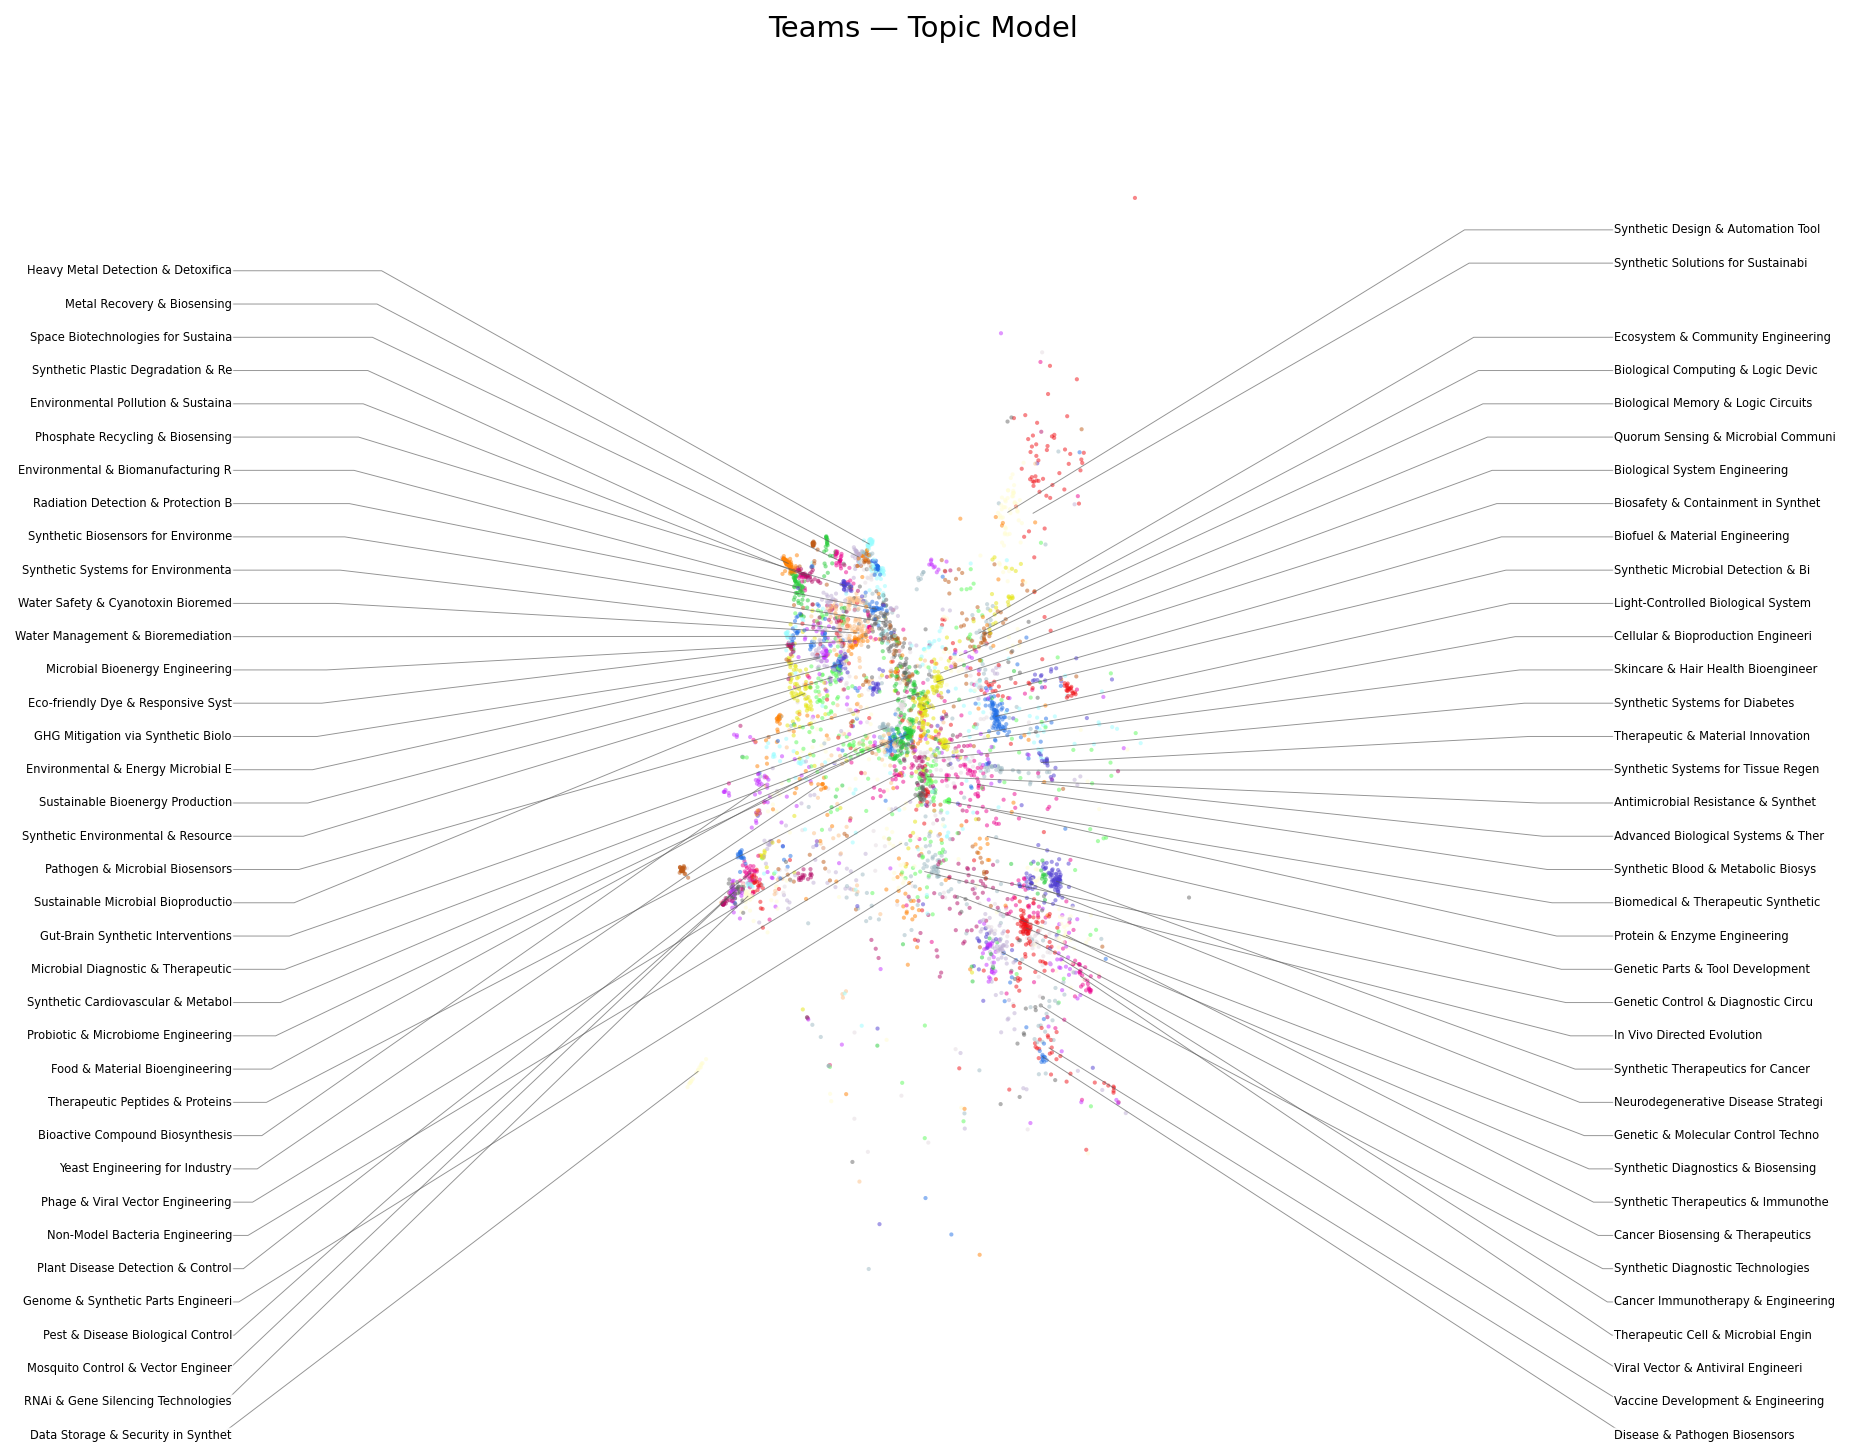

In [ ]:
# --- Teams topic model ---
fig, ax = plot_topic_scatter(df_teams, teams_topics,
                             'Teams — Topic Model',
                             label_min=10,
                             xlim=XLIM, ylim=YLIM)
fig.savefig(os.path.join(REPORTS, 'umap_teams.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'umap_teams.png')}")
plt.show()

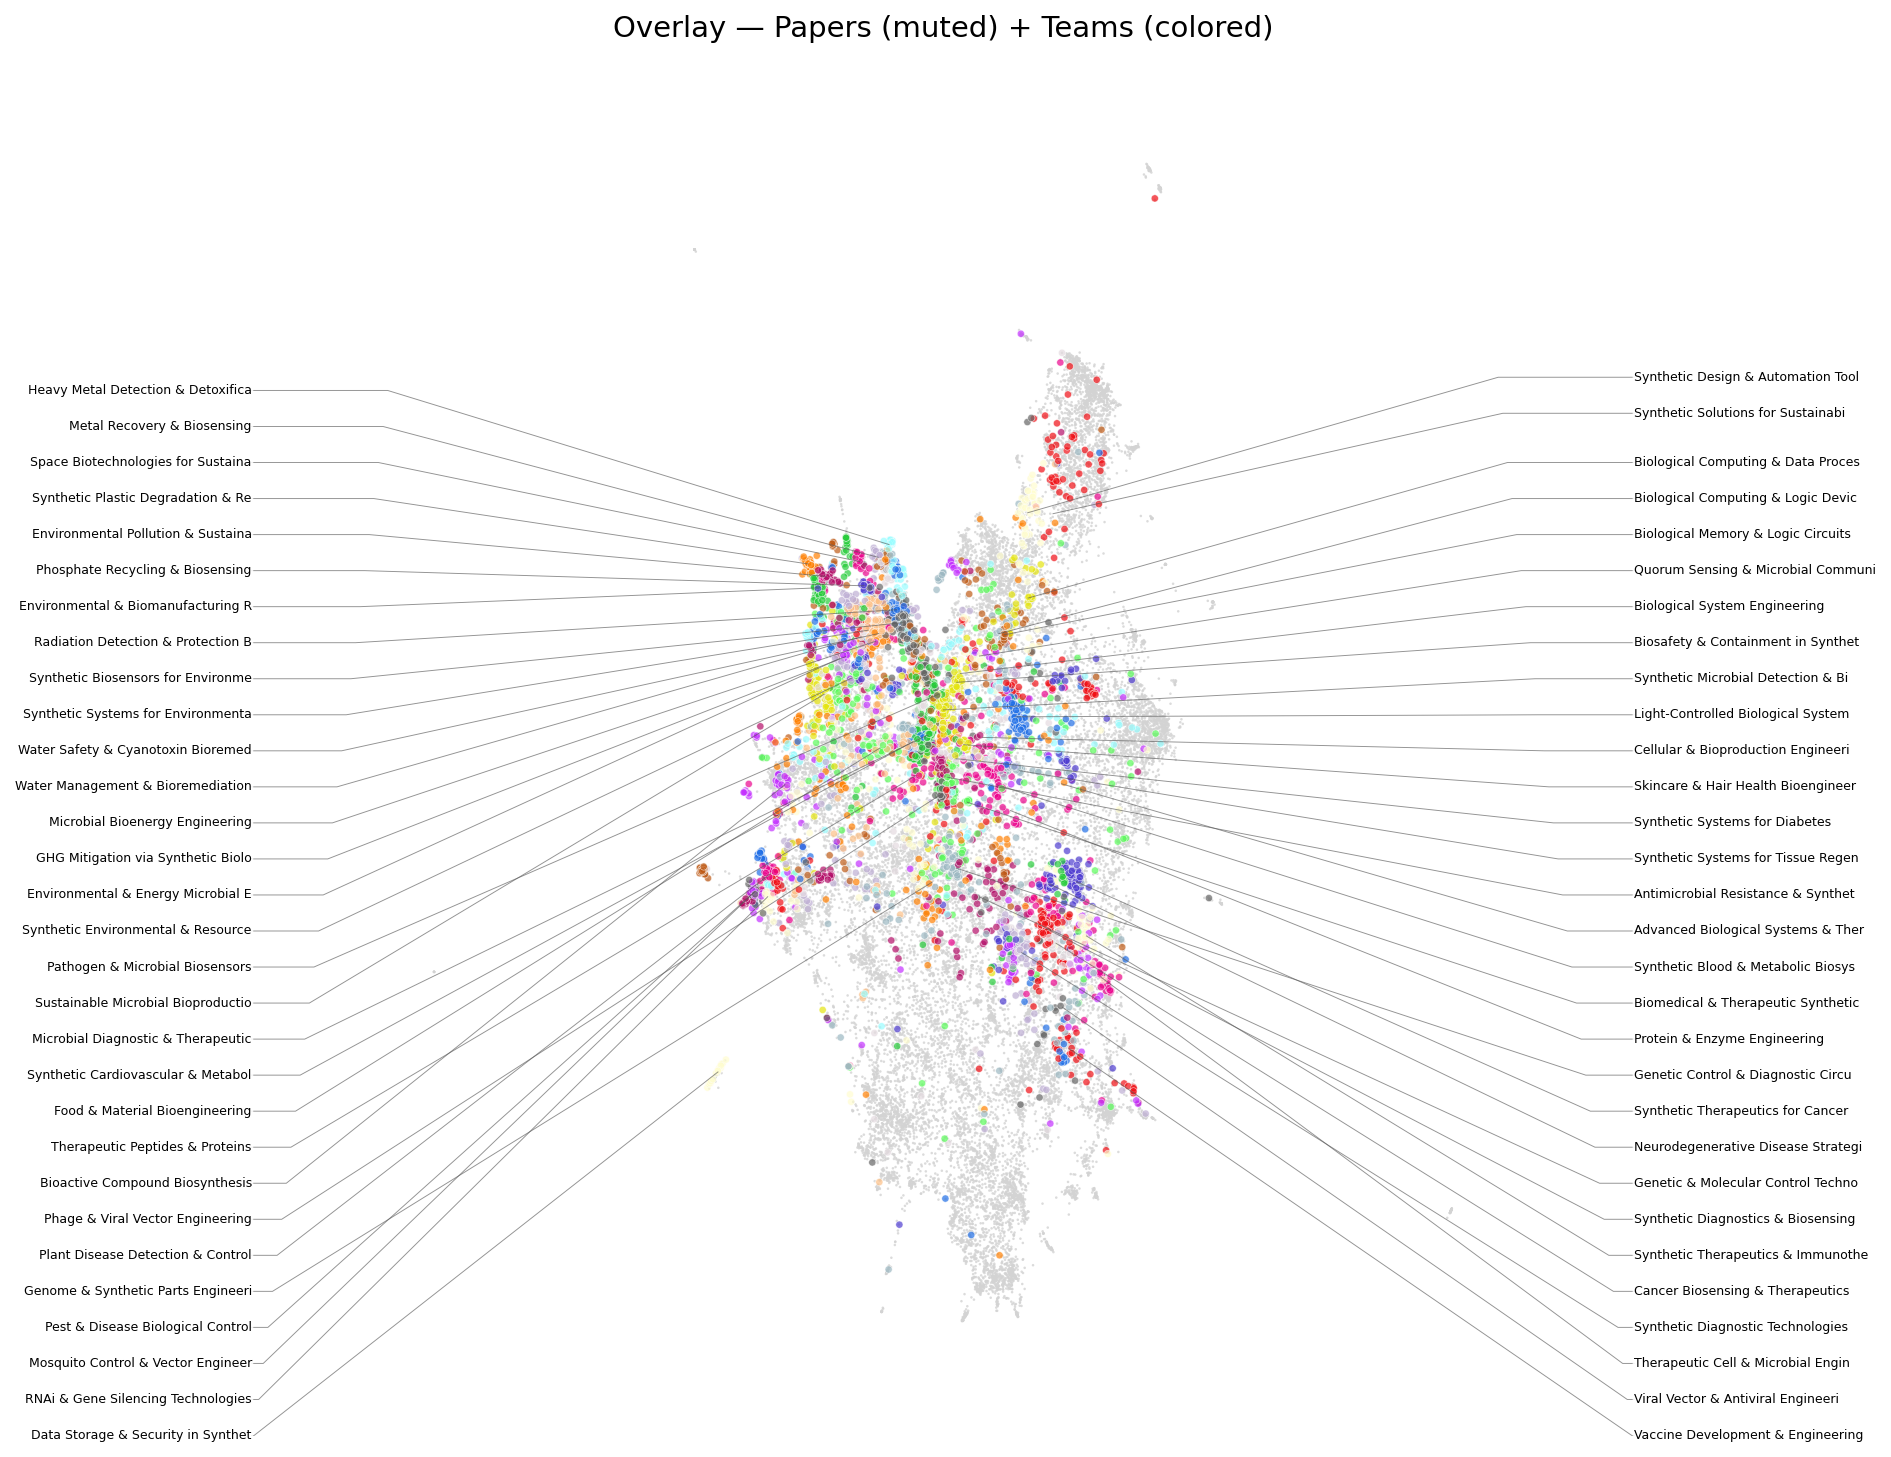

In [ ]:
# --- Overlay: papers (muted) + teams (on top, side-labelled) ---
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Papers layer — muted grey, no labels
ax.scatter(df_papers['x'], df_papers['y'],
           c='#d3d3d3', s=1.5, alpha=0.8, edgecolors='none')

# Teams layer — full color
omask_t = df_teams['topic'] == -1
ax.scatter(df_teams.loc[omask_t, 'x'], df_teams.loc[omask_t, 'y'],
           c='#a0a0a0', s=6, alpha=0.25, edgecolors='none')
ax.scatter(df_teams.loc[~omask_t, 'x'], df_teams.loc[~omask_t, 'y'],
           c=df_teams.loc[~omask_t, 'color'], s=12,
           alpha=0.7, edgecolors='white', linewidth=0.3)

# Teams labels (side placement with anti-overlap)
teams_labels = df_teams[df_teams['topic'] >= 0].groupby('topic').agg(
    cx=('x', 'median'),
    cy=('y', 'median'),
    n_docs=('x', 'size'),
    global_name=('global_name', 'first'),
).reset_index()
teams_labels = teams_labels[teams_labels['n_docs'] >= 10]
add_side_labels(
    ax, teams_labels, XLIM, YLIM,
    fontsize=6,
    min_gap_frac=0.026,
    max_labels_per_side=30,
)

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_title('Overlay — Papers (muted) + Teams (colored)', fontsize=14)
ax.axis('off')
fig.subplots_adjust(left=0.18, right=0.82)
fig.savefig(os.path.join(REPORTS, 'umap_overlay.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'umap_overlay.png')}")
plt.show()

## Density ratio map — Papers vs Teams

We estimate kernel density for each corpus on the same 2D grid, then plot `log₂(teams_density / papers_density)`:
- **Red** regions = teams-dense relative to papers → iGEM activity *ahead* of the literature
- **Blue** regions = papers-dense relative to teams → academic knowledge *not yet adopted* by iGEM
- **White/neutral** = balanced coverage

This directly maps the science–practice gap onto the joint topic space.

In [28]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

# KDE for each corpus (using all points including outliers — we want spatial density)
kde_papers = gaussian_kde(papers_xy.T, bw_method=0.15)
kde_teams  = gaussian_kde(teams_xy.T,  bw_method=0.15)

# Build evaluation grid (reuse shared XLIM/YLIM)
x_min, x_max = XLIM
y_min, y_max = YLIM
grid_res = 300
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                      np.linspace(y_min, y_max, grid_res))
grid_pts = np.vstack([xx.ravel(), yy.ravel()])

# Evaluate densities (normalize to sum to 1 so ratio is scale-independent)
p = kde_papers(grid_pts)
q = kde_teams(grid_pts)
p /= p.sum()
q /= q.sum()

# Log₂ density ratio
eps = 1e-12
ratio = np.log2((q + eps) / (p + eps))
ratio_grid = ratio.reshape(xx.shape)

# Symmetric clipping so the colorscale is centered at 0
vmax = np.percentile(np.abs(ratio_grid), 98)
ratio_grid = np.clip(ratio_grid, -vmax, vmax)

# Smooth per-pixel alpha based on combined density.
# Instead of a hard binary mask, the alpha channel fades smoothly
# from 1 (where data is dense) to 0 (empty space) — no abrupt edges.
p_grid = p.reshape(xx.shape)
q_grid = q.reshape(xx.shape)
combined = p_grid + q_grid
alpha_grid = combined / np.percentile(combined, 95)   # saturate at 95th pctl
alpha_grid = np.clip(alpha_grid, 0, 1)
alpha_grid = gaussian_filter(alpha_grid, sigma=3)      # extra smoothing

print(f"Grid: {grid_res}x{grid_res}, ratio range clipped to ±{vmax:.1f}")

Grid: 300x300, ratio range clipped to ±19.4


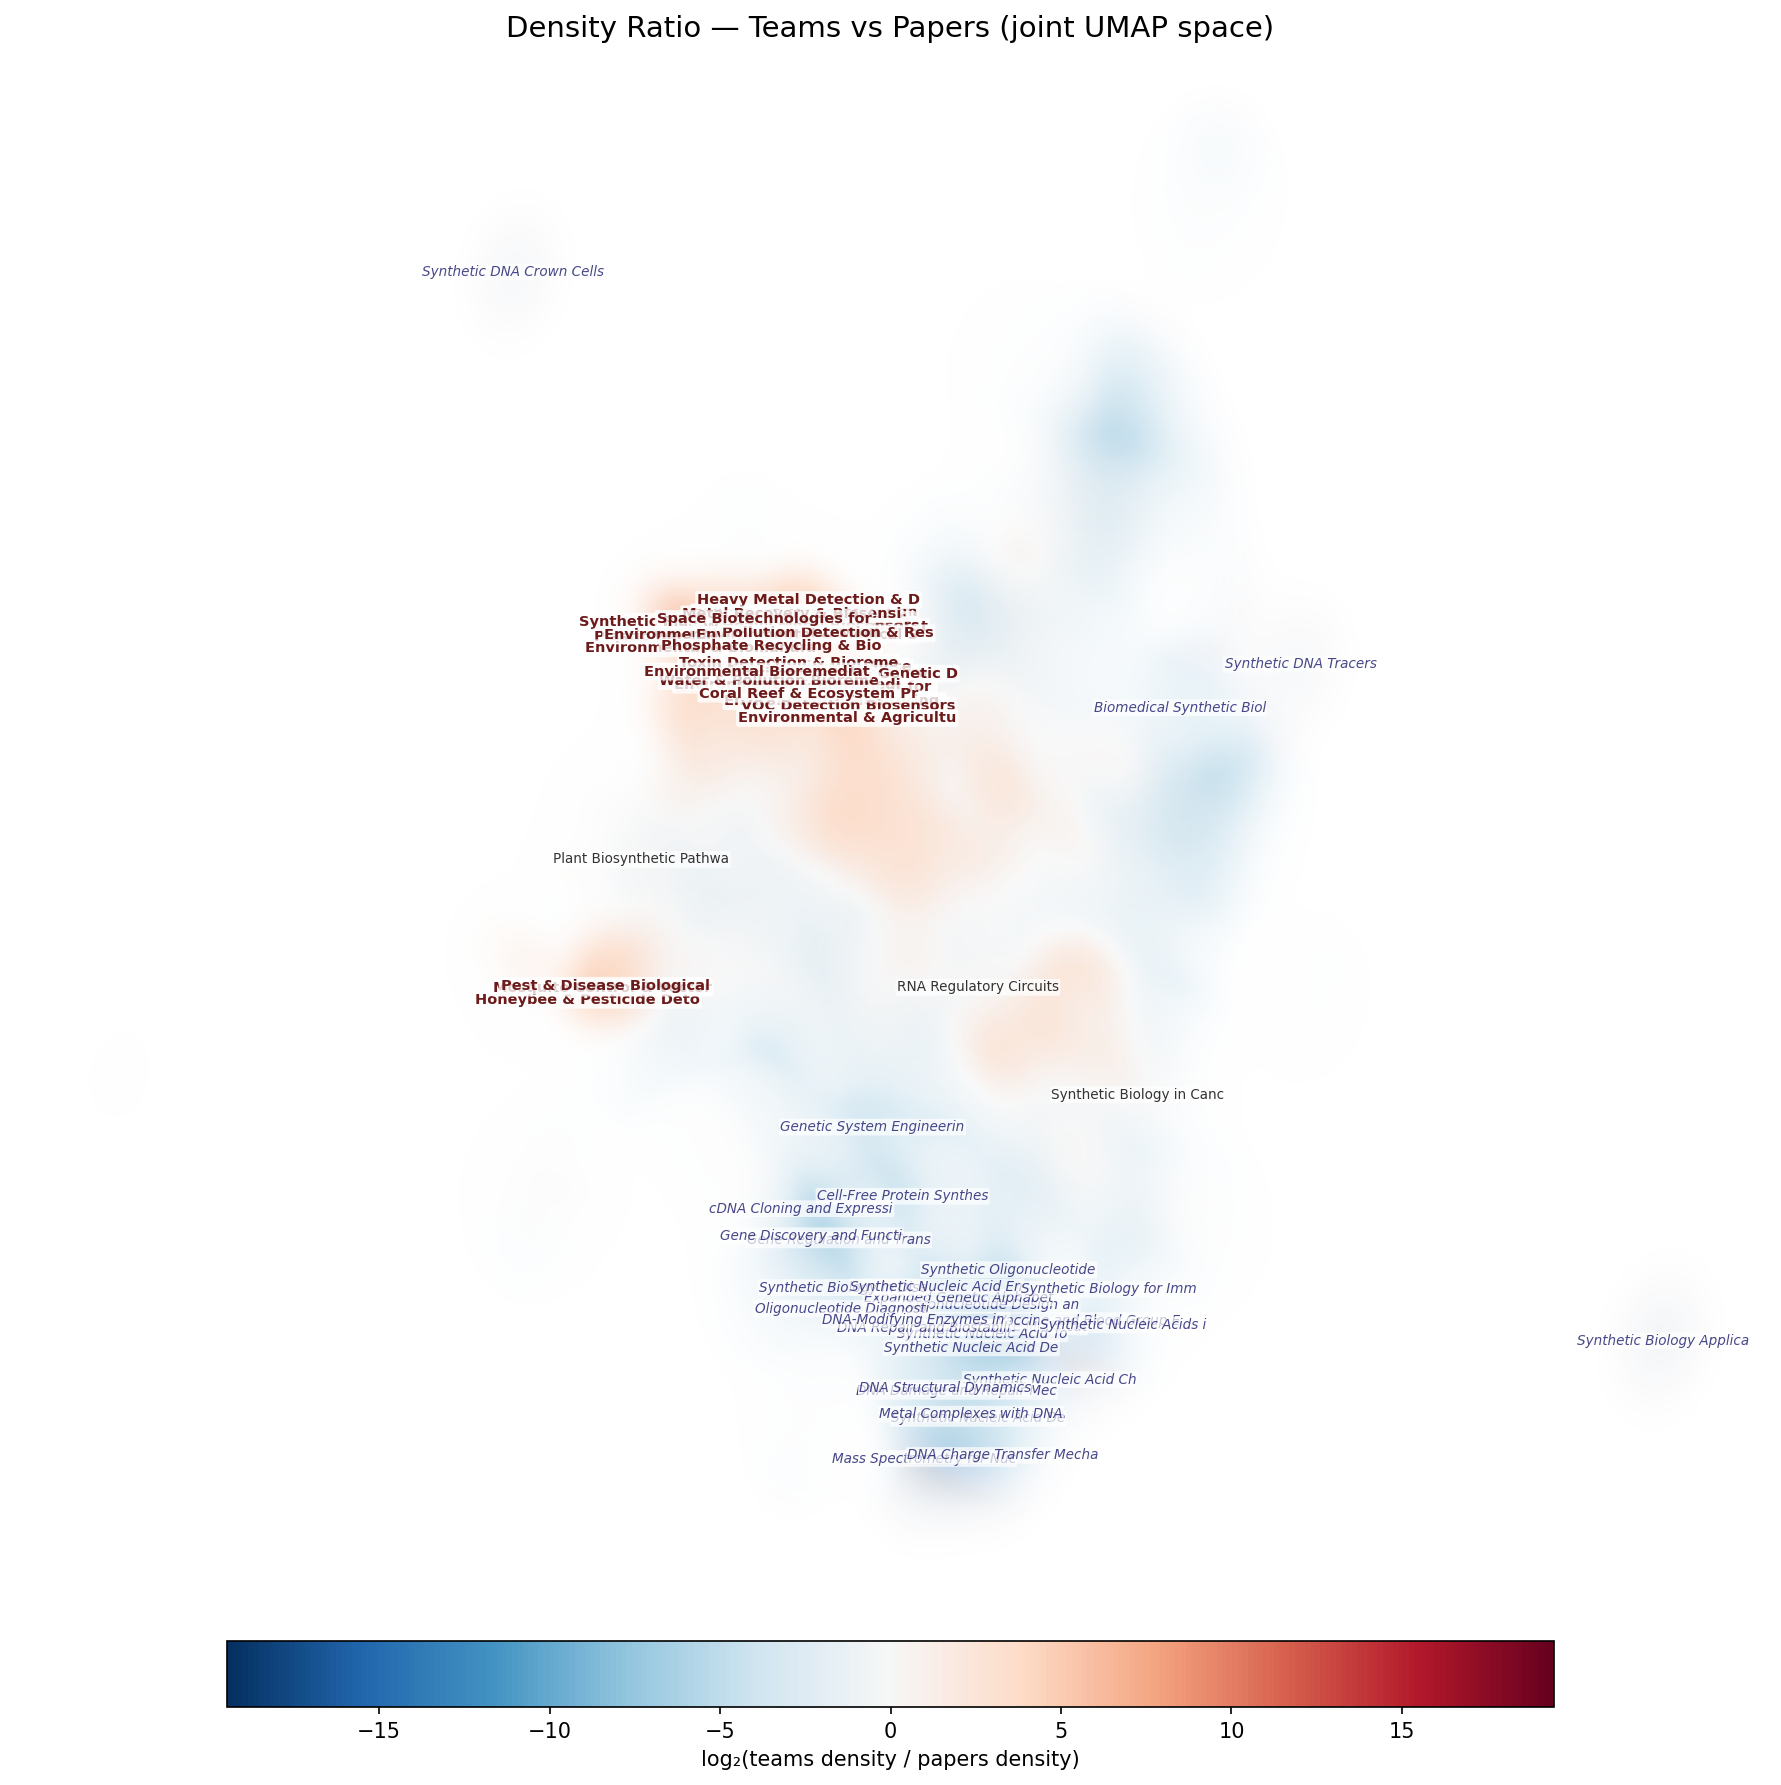

In [29]:
# --- Density ratio heatmap (smooth alpha fade) ---
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Build RGBA image from the RdBu_r colormap + density-based alpha
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
cmap = plt.cm.RdBu_r
rgba = cmap(norm(ratio_grid))        # shape (H, W, 4)
rgba[..., 3] = alpha_grid            # replace alpha with density fade

ax.imshow(
    rgba,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    aspect='auto',
    interpolation='bilinear',
)

# Dummy ScalarMappable for colorbar (imshow RGBA has no built-in one)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.04, pad=0.03)
cbar.set_label('log₂(teams density / papers density)', fontsize=10)

# --- Label selection logic ---
# Compute per-topic density ratio at centroid for both teams and papers
from scipy.interpolate import RegularGridInterpolator
ratio_interp = RegularGridInterpolator(
    (np.linspace(y_min, y_max, grid_res), np.linspace(x_min, x_max, grid_res)),
    np.ma.filled(ratio_grid, fill_value=0),
    method='linear', bounds_error=False, fill_value=0
)

# Teams topic centroids
teams_ctr = df_teams[df_teams['topic'] >= 0].groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'), n_docs=('x', 'size'), global_name=('global_name', 'first')
).reset_index()
teams_ctr['log2_ratio'] = ratio_interp(np.column_stack([teams_ctr['cy'], teams_ctr['cx']]))

# Papers topic centroids
papers_ctr = df_papers[df_papers['topic'] >= 0].groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'), n_docs=('x', 'size'), global_name=('global_name', 'first')
).reset_index()
papers_ctr['log2_ratio'] = ratio_interp(np.column_stack([papers_ctr['cy'], papers_ctr['cx']]))

# Show top N teams-dominant, top N papers-dominant, and a few overlap topics
N = 30
show_teams = teams_ctr.sort_values('log2_ratio', ascending=False).head(N)
show_papers = papers_ctr.sort_values('log2_ratio', ascending=True).head(N)
# Optionally, show a few overlap topics (ratio near zero, both n_docs high)
overlap = papers_ctr.loc[(papers_ctr['log2_ratio'].abs() < 0.5)]
overlap = overlap.sort_values('n_docs', ascending=False).head(3)

# Overlay teams-dominant topic labels (red-ish, bold)
for _, row in show_teams.iterrows():
    ax.text(row['cx'], row['cy'], str(row['global_name'])[:25], fontsize=7, fontweight='bold',
            ha='center', va='center', color='#6c1a1a',
            bbox=dict(boxstyle='round,pad=0.13', fc='white', alpha=0.8, ec='none'))

# Overlay papers-dominant topic labels (blue-ish, italic)
for _, row in show_papers.iterrows():
    ax.text(row['cx'], row['cy'], str(row['global_name'])[:25], fontsize=6.5, fontstyle='italic',
            ha='center', va='center', color='#1a1a6c', alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.10', fc='white', alpha=0.7, ec='none'))

# Overlay a few overlap topics (black, normal)
for _, row in overlap.iterrows():
    ax.text(row['cx'], row['cy'], str(row['global_name'])[:25], fontsize=6.5,
            ha='center', va='center', color='black', alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.10', fc='white', alpha=0.7, ec='none'))

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_title('Density Ratio — Teams vs Papers (joint UMAP space)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [30]:
# --- Quantitative overlap metrics ---

from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

# ── 1. Interpolate pre-computed ratio grid at topic centroids ────────
#    Avoids expensive per-topic KDE evaluation — just samples the grid.
x_vals = np.linspace(*XLIM, grid_res)
y_vals = np.linspace(*YLIM, grid_res)
ratio_filled = np.ma.filled(ratio_grid, fill_value=np.nan)
ratio_interp = RegularGridInterpolator(
    (y_vals, x_vals), ratio_filled,
    method='linear', bounds_error=False, fill_value=np.nan
)

# ── 2. Papers topic centroids + density ratio ────────────────────────
_df_p = df_papers[df_papers['topic'] >= 0].copy()
_df_p = _df_p.merge(papers[['id', 'publication_year']], on='id', how='left')

papers_ctr = _df_p.groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'),
    n_docs=('x', 'size'),
    avg_year=('publication_year', 'mean'),
    global_name=('global_name', 'first'),
).reset_index()
papers_ctr['log2_ratio'] = ratio_interp(
    np.column_stack([papers_ctr['cy'].values, papers_ctr['cx'].values])
)

# ── 3. Teams topic centroids + density ratio ─────────────────────────
teams_raw = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t', usecols=['UT', 'Year_y'])
teams_raw['Year_y'] = pd.to_numeric(teams_raw['Year_y'], errors='coerce')

_df_t = df_teams[df_teams['topic'] >= 0].copy()
_df_t = _df_t.merge(teams_raw, on='UT', how='left')

teams_ctr = _df_t.groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'),
    n_docs=('x', 'size'),
    avg_year=('Year_y', 'mean'),
    global_name=('global_name', 'first'),
).reset_index()
teams_ctr['log2_ratio'] = ratio_interp(
    np.column_stack([teams_ctr['cy'].values, teams_ctr['cx'].values])
)

# ── 4. Classify topics by coverage zone ──────────────────────────────
#    |log2_ratio| > 1 ≈ one corpus has >2× the density of the other
def classify(r):
    if pd.isna(r): return 'unmapped'
    if r > 1:  return 'teams-dominant'
    if r < -1: return 'papers-only'
    return 'overlap'

papers_ctr['zone'] = papers_ctr['log2_ratio'].apply(classify)
teams_ctr['zone']  = teams_ctr['log2_ratio'].apply(classify)

print("=== Papers topics by zone ===")
print(papers_ctr['zone'].value_counts().to_string())
print(f"\n=== Teams topics by zone ===")
print(teams_ctr['zone'].value_counts().to_string())

# ── 5. Temporal precedence for overlap papers topics ─────────────────
#    For each papers topic in the overlap zone, find spatially nearby
#    teams via KD-tree and compare average years.
teams_tree = cKDTree(teams_xy)
_df_t_full = df_teams.merge(teams_raw, on='UT', how='left')

precedence = []
overlap_topics = papers_ctr[papers_ctr['zone'] == 'overlap']

for _, row in overlap_topics.iterrows():
    # Search radius: median intra-cluster distance × 1.5
    topic_pts = _df_p.loc[_df_p['topic'] == row['topic'], ['x', 'y']].values
    dists = np.sqrt((topic_pts[:, 0] - row['cx'])**2 +
                    (topic_pts[:, 1] - row['cy'])**2)
    radius = np.median(dists) * 1.5

    nearby_idx = teams_tree.query_ball_point([row['cx'], row['cy']], r=radius)
    nearby_years = _df_t_full.iloc[nearby_idx]['Year_y'].dropna()
    if len(nearby_years) < 3:
        continue

    delta = nearby_years.mean() - row['avg_year']
    precedence.append({
        'topic': row['topic'],
        'global_name': row['global_name'],
        'n_papers': row['n_docs'],
        'n_nearby_teams': len(nearby_idx),
        'avg_year_papers': round(row['avg_year'], 1),
        'avg_year_teams': round(nearby_years.mean(), 1),
        'delta_years': round(delta, 2),
    })

df_prec = pd.DataFrame(precedence).sort_values('delta_years')

print(f"\n{'='*65}")
print(f"Temporal precedence — {len(df_prec)} overlap topics with nearby teams")
print(f"  delta < 0 → iGEM teams PRECEDED the literature")
print(f"  delta > 0 → literature PRECEDED iGEM teams")
print(f"{'='*65}")

cols = ['global_name', 'n_papers', 'n_nearby_teams',
        'avg_year_papers', 'avg_year_teams', 'delta_years']

print(f"\niGEM preceded ({(df_prec['delta_years'] < 0).sum()} topics):")
print(df_prec[df_prec['delta_years'] < 0].head(15)[cols].to_string(index=False))
print(f"\nLiterature preceded ({(df_prec['delta_years'] > 0).sum()} topics):")
print(df_prec[df_prec['delta_years'] > 0].tail(15)[cols].to_string(index=False))

# ── 6. Save tables to assets/reports/ ────────────────────────────────
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

df_igem_preceded = df_prec[df_prec['delta_years'] < 0].copy()
df_lit_preceded  = df_prec[df_prec['delta_years'] > 0].copy()

df_igem_preceded.to_csv(os.path.join(REPORTS, 'igem_preceded.tsv'), sep='\t', index=False)
df_lit_preceded.to_csv(os.path.join(REPORTS, 'literature_preceded.tsv'), sep='\t', index=False)

print(f"\nSaved to {REPORTS}/:")
print(f"  igem_preceded.tsv        ({len(df_igem_preceded)} rows)")
print(f"  literature_preceded.tsv  ({len(df_lit_preceded)} rows)")

=== Papers topics by zone ===
zone
papers-only       148
overlap            83
teams-dominant     32

=== Teams topics by zone ===
zone
teams-dominant    115
overlap            44
papers-only         2

Temporal precedence — 70 overlap topics with nearby teams
  delta < 0 → iGEM teams PRECEDED the literature
  delta > 0 → literature PRECEDED iGEM teams

iGEM preceded (34 topics):
                                     global_name  n_papers  n_nearby_teams  avg_year_papers  avg_year_teams  delta_years
                         AI in Synthetic Biology        27              21           2022.8          2016.9        -5.96
                   Microbial Chassis Development        25               9           2018.8          2014.3        -4.47
                     CRISPR in Synthetic Biology        32              35           2021.3          2016.9        -4.46
             AI-Driven Imaging and Data Analysis        44               7           2019.1          2014.7        -4.42
            